In [4]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm, t
import matplotlib.pyplot as plt

In [5]:
binary_dataset = pd.read_excel("/Users/apple/downloads/BinaryData40.xlsx")

y = binary_dataset["Y"].values
x = binary_dataset["X1"].values
n = len(y)

X = np.column_stack((np.ones(n), x))

In [6]:
# the loglikelyhood function 
def loglik(beta, model, nu=None):

    xb = X @ beta

    if model == "logit":
        p = 1/(1+np.exp(-xb))

    elif model == "probit":
        p = norm.cdf(xb)

    elif model == "cloglog":
        p = 1 - np.exp(-np.exp(xb))

    elif model == "loglog":
        p = np.exp(-np.exp(-xb))

    elif model == "gosset":
        p = t.cdf(xb, df=nu)

    eps = 1e-10
    p = np.clip(p, eps, 1-eps)

    ll = y*np.log(p) + (1-y)*np.log(1-p)

    return -np.sum(ll)

In [7]:
# estimating the models
results = {}

beta_start = np.array([0,0])

models = ["logit","probit","cloglog","loglog"]

for m in models:

    res = minimize(loglik, beta_start, args=(m))
    beta = res.x

    LL = -res.fun
    k = len(beta)

    AIC = -2*LL + 2*k
    SC = -2*LL + k*np.log(n)

    xb = X @ beta

    if m=="logit":
        p = 1/(1+np.exp(-xb))
    elif m=="probit":
        p = norm.cdf(xb)
    elif m=="cloglog":
        p = 1 - np.exp(-np.exp(xb))
    elif m=="loglog":
        p = np.exp(-np.exp(-xb))

    yhat = (p>0.5).astype(int)
    acc = np.mean(yhat==y)

    results[m] = [beta,LL,AIC,SC,acc]

In [8]:
# estimating student-t model (gosset)
def loglik_student_t(params):

    beta = params[:2]
    nu = np.exp(params[2])   

    xb = X @ beta
    p = t.cdf(xb, df=nu)

    eps = 1e-10
    p = np.clip(p, eps, 1-eps)

    ll = y*np.log(p) + (1-y)*np.log(1-p)

    return -np.sum(ll)


start = np.array([0,0,1])

res = minimize(loglik_student_t, start)

beta = res.x[:2]
nu = np.exp(res.x[2])

LL = -res.fun
k = 3

AIC = -2*LL + 2*k
SC = -2*LL + k*np.log(n)

xb = X @ beta
p = t.cdf(xb,df=nu)

yhat = (p>0.5).astype(int)
acc = np.mean(yhat==y)

results["Student-t"] = [beta,LL,AIC,SC,acc,nu]

In [9]:
# model comparisons
print("Model comparison:\n")

for m,r in results.items():

    beta = r[0]
    LL = r[1]
    AIC = r[2]
    SC = r[3]
    acc = r[4]

    print(m)
    print("beta:",beta)
    print("LL:",LL)
    print("AIC:",AIC)
    print("SC:",SC)
    print("Accuracy:",acc)
    print()

best_model = min(results, key=lambda k: results[k][2])

print("Model selection based on AIC")
print(f"\nThe model with the lowest AIC is: {best_model}")
print(f"AIC = {results[best_model][2]}")
print("\nBecause the lowest AIC results into the best model, this is the model chosen as a best fit.")


Model comparison:

logit
beta: [-20.1551765    1.12414169]
LL: -259.4920890370149
AIC: 522.9841780740298
SC: 533.6106188482105
Accuracy: 0.9153333333333333

probit
beta: [-10.96185541   0.6135296 ]
LL: -260.29475942542723
AIC: 524.5895188508545
SC: 535.2159596250351
Accuracy: 0.9153333333333333

cloglog
beta: [-15.22716874   0.81671844]
LL: -248.89858015559545
AIC: 501.7971603111909
SC: 512.4236010853715
Accuracy: 0.9313333333333333

loglog
beta: [-9.93657434  0.58840547]
LL: -291.67871984431747
AIC: 587.3574396886349
SC: 597.9838804628156
Accuracy: 0.9153333333333333

Student-t
beta: [-10.96185496   0.61352958]
LL: -260.294759414645
AIC: 526.58951882929
SC: 542.5291799905609
Accuracy: 0.9153333333333333

Model selection based on AIC

The model with the lowest AIC is: cloglog
AIC = 501.7971603111909

Because the lowest AIC results into the best model, this is the model chosen as a best fit.


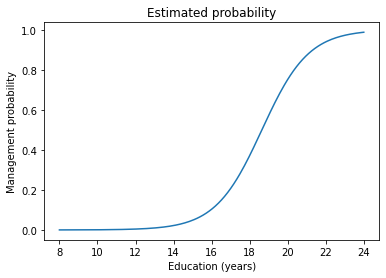

In [10]:
# plotting estimated probability of best model
# AIC is lowest for cloglog so that is the model used
beta = results["cloglog"][0]

x_grid = np.linspace(min(x),max(x),200)
Xg = np.column_stack((np.ones(len(x_grid)),x_grid))

p = 1/(1+np.exp(-(Xg@beta)))

plt.plot(x_grid,p)
plt.xlabel("Education (years)")
plt.ylabel("Management probability")
plt.title("Estimated probability")
plt.show()


In [11]:
# partial effects - PEA
x_bar = np.mean(x)

xb = beta[0] + beta[1]*x_bar
p = 1/(1+np.exp(-xb))

PEA = beta[1]*p*(1-p)

print("\nPEA =",PEA)


PEA = 0.07347158354762512


In [12]:
# partial effects - APE
xb = beta[0] + beta[1]*x
p = 1/(1+np.exp(-xb))

APE = np.mean(beta[1]*p*(1-p))

print("APE =",APE)


APE = 0.059035823591203025


In [13]:
print(f"\nFor a person with an average education level, one extra year of education increases the probability of having a management job by {PEA*100:.1f}%.")
print(f"For all people on average, one extra year of education increases the probability of having a management job by {APE*100:.1f}%.")



For a person with an average education level, one extra year of education increases the probability of having a management job by 7.3%.
For all people on average, one extra year of education increases the probability of having a management job by 5.9%.


In [14]:
# verifying coefficient flip 
y_tilde = 1 - y

def loglik_logit(beta):

    xb = X@beta
    p = 1/(1+np.exp(-xb))

    eps = 1e-10
    p = np.clip(p,eps,1-eps)

    ll = y_tilde*np.log(p)+(1-y_tilde)*np.log(1-p)

    return -np.sum(ll)

res = minimize(loglik_logit,[0,0])

beta_tilde = res.x

print("\nOriginal beta:",results["logit"][0])
print("New beta:",beta_tilde)
print("\nBecause the estimated coefficients are approximately flipped compared to the original Logit model, we confirm the theoretical property of the symmetric model.")



Original beta: [-20.1551765    1.12414169]
New beta: [20.15520096 -1.12414306]

Because the estimated coefficients are approximately flipped compared to the original Logit model, we confirm the theoretical property of the symmetric model.
